In [1]:
# --- IMPORTS & DATA PREPARATION ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Stap 1: Data inlezen
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

# Stap 2: Verwijder rijen met lege waarden voor de belangrijkste features
df = df.dropna(subset=['Garage', 'Overall Qual', 'Year Built', 'Gr Liv Area', 'Neighborhood', 'SalePrice'])
print("✅ Data is succesvol geladen en voorbereid!")

✅ Data is succesvol geladen en voorbereid!


DEEL 1: GARAGE VOORSPELLEN (Binary Classification)
Exp 1 (Basis, Depth 3) Accuracy: 0.9369
Exp 2 (Depth 7) Accuracy: 0.9283
Exp 3 (Entropy Criterion) Accuracy: 0.9352
Exp 4 (Class Weight Balanced) Accuracy: 0.8652
Exp 5 (Pruning: min_samples_leaf=15) Accuracy: 0.9352
Exp 6 (Random Forest 50 trees) Accuracy: 0.9488
Exp 7 (Finaal Garage Model) Accuracy: 0.9437

--- Classification Report (Finaal Garage Model) ---
              precision    recall  f1-score   support

          no       1.00      0.11      0.20        37
         yes       0.94      1.00      0.97       549

    accuracy                           0.94       586
   macro avg       0.97      0.55      0.58       586
weighted avg       0.95      0.94      0.92       586



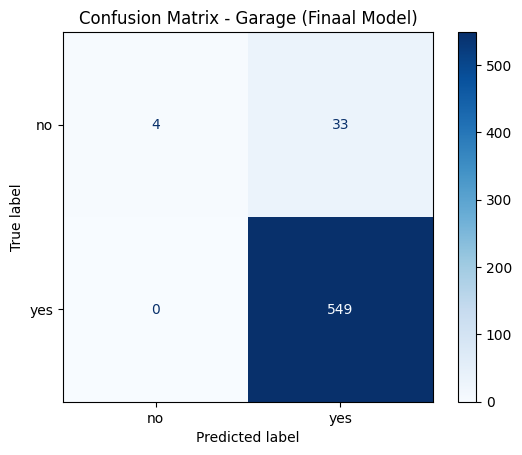

In [2]:
# =====================================================================
# DEEL 1: GARAGE CLASSIFICATIE (Experiment 1 t/m 7)
# =====================================================================
print("="*50, "\nDEEL 1: GARAGE VOORSPELLEN (Binary Classification)\n", "="*50)

# Basis data voor Garage
X_gar = df[['Year Built', 'Gr Liv Area', 'Neighborhood', 'SalePrice', 'House Style']].copy()
X_gar_enc = pd.get_dummies(X_gar, drop_first=True)
y_gar = df['Garage']

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_gar_enc, y_gar, test_size=0.2, random_state=42)

# --- EXPERIMENTEN ---
# Exp 1: Initiële Run (max_depth=3)
dt_1 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_g, y_train_g)
print(f"Exp 1 (Basis, Depth 3) Accuracy: {accuracy_score(y_test_g, dt_1.predict(X_test_g)):.4f}")

# Exp 2: Diepere boom (max_depth=7)
dt_2 = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_train_g, y_train_g)
print(f"Exp 2 (Depth 7) Accuracy: {accuracy_score(y_test_g, dt_2.predict(X_test_g)):.4f}")

# Exp 3: Criterion 'Entropy' in plaats van 'Gini' (Wiskundige verandering)
dt_3 = DecisionTreeClassifier(max_depth=7, criterion='entropy', random_state=42).fit(X_train_g, y_train_g)
print(f"Exp 3 (Entropy Criterion) Accuracy: {accuracy_score(y_test_g, dt_3.predict(X_test_g)):.4f}")

# Exp 4: Class Weight Balanced (Voor ongelijke data verdeling)
dt_4 = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42).fit(X_train_g, y_train_g)
print(f"Exp 4 (Class Weight Balanced) Accuracy: {accuracy_score(y_test_g, dt_4.predict(X_test_g)):.4f}")

# Exp 5: Pruning (min_samples_leaf=15) om overfitting te voorkomen
dt_5 = DecisionTreeClassifier(max_depth=None, min_samples_leaf=15, random_state=42).fit(X_train_g, y_train_g)
print(f"Exp 5 (Pruning: min_samples_leaf=15) Accuracy: {accuracy_score(y_test_g, dt_5.predict(X_test_g)):.4f}")

# Exp 6: Introductie van Random Forest (Ensemble van 50 bomen)
rf_6 = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_train_g, y_train_g)
print(f"Exp 6 (Random Forest 50 trees) Accuracy: {accuracy_score(y_test_g, rf_6.predict(X_test_g)):.4f}")

# Exp 7: Finaal Geoptimaliseerd Model
model_garage_final = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_garage_final.fit(X_train_g, y_train_g)
y_pred_gf = model_garage_final.predict(X_test_g)
print(f"Exp 7 (Finaal Garage Model) Accuracy: {accuracy_score(y_test_g, y_pred_gf):.4f}\n")

# --- RAPPORT & VISUALISATIE ---
print("--- Classification Report (Finaal Garage Model) ---")
print(classification_report(y_test_g, y_pred_gf))

# De ultieme visualisatie (Confusion Matrix)
ConfusionMatrixDisplay.from_predictions(y_test_g, y_pred_gf, cmap='Blues')
plt.title("Confusion Matrix - Garage (Finaal Model)")
plt.show()


DEEL 2: KWALITEIT VOORSPELLEN (Multi-class)
Exp 8 (Basis, Depth 3) Accuracy: 0.5154
Exp 9 (Ongelimiteerde Diepte) Accuracy: 0.5375
Exp 10 (Pruning: min_samples_split=20) Accuracy: 0.5546
Exp 11 (max_features='sqrt') Accuracy: 0.5358
Exp 12 (Class Weight Balanced) Accuracy: 0.5324
Exp 13 (Random Forest 50 trees) Accuracy: 0.5887
Exp 14 (Random Forest 100 trees) Accuracy: 0.6126
Exp 15 (Finaal Kwaliteit Model) Accuracy: 0.6041

--- Classification Report (Finaal Kwaliteit Model) ---
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         3
           3       0.50      0.10      0.17        10
           4       0.47      0.39      0.43        49
           5       0.61      0.79      0.69       150
           6       0.54      0.46      0.50       119
           7       0.67      0.67      0.67       137
           8       0.64      0.65      0.65        83
           9       0.52      0.54      0.53        26
          10       1.00    

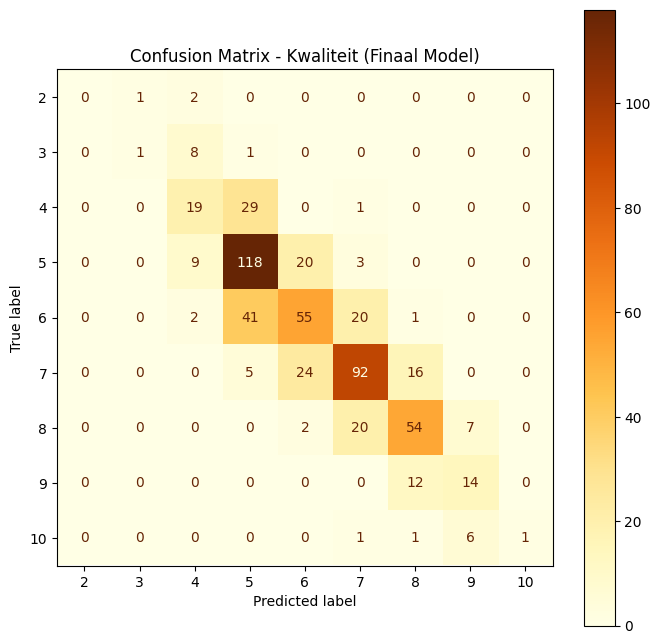

In [3]:
# =====================================================================
# DEEL 2: KWALITEIT CLASSIFICATIE (Experiment 8 t/m 15)
# =====================================================================
print("\n" + "="*50, "\nDEEL 2: KWALITEIT VOORSPELLEN (Multi-class)\n", "="*50)

# Basis data voor Kwaliteit
X_qual = df[['Gr Liv Area', 'Year Built', 'Neighborhood', 'SalePrice', 'Full Bath']].copy()
X_qual_enc = pd.get_dummies(X_qual, drop_first=True)
y_qual = df['Overall Qual']

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_qual_enc, y_qual, test_size=0.2, random_state=42)

# --- EXPERIMENTEN ---
# Exp 8: Initiële Run (max_depth=3)
dt_8 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 8 (Basis, Depth 3) Accuracy: {accuracy_score(y_test_q, dt_8.predict(X_test_q)):.4f}")

# Exp 9: Ongelimiteerde diepte (max_depth=None - veroorzaakt vaak overfitting)
dt_9 = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 9 (Ongelimiteerde Diepte) Accuracy: {accuracy_score(y_test_q, dt_9.predict(X_test_q)):.4f}")

# Exp 10: Pruning met min_samples_split
dt_10 = DecisionTreeClassifier(max_depth=None, min_samples_split=20, random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 10 (Pruning: min_samples_split=20) Accuracy: {accuracy_score(y_test_q, dt_10.predict(X_test_q)):.4f}")

# Exp 11: Feature restrictie (max_features='sqrt')
dt_11 = DecisionTreeClassifier(max_depth=15, max_features='sqrt', random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 11 (max_features='sqrt') Accuracy: {accuracy_score(y_test_q, dt_11.predict(X_test_q)):.4f}")

# Exp 12: Class Weight Balanced (Omdat kwaliteit 1 of 10 zelden voorkomen)
dt_12 = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 12 (Class Weight Balanced) Accuracy: {accuracy_score(y_test_q, dt_12.predict(X_test_q)):.4f}")

# Exp 13: Random Forest Basis
rf_13 = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 13 (Random Forest 50 trees) Accuracy: {accuracy_score(y_test_q, rf_13.predict(X_test_q)):.4f}")

# Exp 14: Random Forest met meer bomen en gecontroleerde diepte
rf_14 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42).fit(X_train_q, y_train_q)
print(f"Exp 14 (Random Forest 100 trees) Accuracy: {accuracy_score(y_test_q, rf_14.predict(X_test_q)):.4f}")

# Exp 15: Finaal Geoptimaliseerd Model
model_qual_final = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42)
model_qual_final.fit(X_train_q, y_train_q)
y_pred_qf = model_qual_final.predict(X_test_q)
print(f"Exp 15 (Finaal Kwaliteit Model) Accuracy: {accuracy_score(y_test_q, y_pred_qf):.4f}\n")

# --- RAPPORT & VISUALISATIE ---
print("--- Classification Report (Finaal Kwaliteit Model) ---")
# zero_division=0 voorkomt waarschuwingen als een categorie 0 keer geraden is
print(classification_report(y_test_q, y_pred_qf, zero_division=0))

# Visualisatie voor multi-class
ConfusionMatrixDisplay.from_predictions(y_test_q, y_pred_qf, cmap='YlOrBr')
plt.title("Confusion Matrix - Kwaliteit (Finaal Model)")
fig = plt.gcf()
fig.set_size_inches(8, 8) # Grotere afbeelding voor multi-class
plt.show()